In [55]:
import pandas as pd
from bs4 import BeautifulSoup
import requests
import numpy as np
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew
import miceforest as mf

## 1) Scraping GICS from Wikipedia:

In [56]:
# url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
# response = requests.get(url)
# soup = BeautifulSoup(response.text, 'html.parser')
# table = soup.find('tbody')
# data = []
# rows = table.find_all('tr')
# for row in rows:
#   cells = row.find_all('td')
#   row_data = [cell.get_text(strip=True) for cell in cells]
#   data.append(row_data)

# symbol_wiki = pd.DataFrame(data)
# columns = ['Symbol', 'Security', 'GICS Sector', 'GICS Sub-Industry', 'Headquarters Location', 'Date Added', 'CIK', 'Founded']
# symbol_wiki.columns = columns
# symbol_wiki = symbol_wiki.iloc[1:]
# #print(symbol_wiki.head())
#symbol_wiki.to_excel("Data/symbol_wiki.xlsx", index = False)

In [57]:
symbol_wiki = pd.read_excel("Data/symbol_wiki.xlsx")

Read the dataset with the symbol for each company of the S&P 500 (composition of december 2022), to match it with GICS data from wikipedia:

In [58]:
type_lseg = pd.read_excel("Data/symbol_comp_1222.xlsm", sheet_name="SYMBOL", dtype=str).iloc[0].values[1:]

In [59]:
symbol_lseg = pd.read_excel("Data/symbol_comp_1222.xlsm", sheet_name="SYMBOL", dtype=str, header=2)

In [60]:
symbol_lseg = symbol_lseg.iloc[:1].transpose().reset_index().rename(columns= {"index": "NAME", 0: "SYMBOL"}).iloc[1:]

In [61]:
symbol_lseg['TYPE'] = type_lseg

In [62]:
#symbol_lseg.head()

In [63]:
#symbol_wiki.head()

In [64]:
gics = pd.merge(symbol_lseg, symbol_wiki[['Symbol', 'GICS Sector']], how = 'left', left_on = 'SYMBOL', right_on='Symbol')

## 2) Fill the missing GICS values manually from online sources:

In [65]:
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ROBERT HALF"), 'GICS Sector'] = 'Industrials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ALASKA AIR GROUP"), 'GICS Sector'] = 'Industrials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "AMERICAN AIRLINES GROUP"), 'GICS Sector'] = 'Industrials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "BIO-RAD LABORATORIES 'A'"), 'GICS Sector'] = 'Health Care'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "TELEFLEX"), 'GICS Sector'] = 'Health Care'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ILLUMINA"), 'GICS Sector'] = 'Health Care'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "CATALENT DEAD - DELIST.18/12/24"), 'GICS Sector'] = 'Health Care'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "DENTSPLY SIRONA"), 'GICS Sector'] = 'Health Care'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ORGANON"), 'GICS Sector'] = 'Health Care'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ETSY"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "BORGWARNER"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "V F"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "WHIRLPOOL"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "BATH AND BODY WORKS"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ADV.AUTO PARTS"), 'GICS Sector'] = 'Consumer Discretionary'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "WESTROCK DEAD - DELIST.08/07/24"), 'GICS Sector'] = 'Materials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "CELANESE"), 'GICS Sector'] = 'Materials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "FMC"), 'GICS Sector'] = 'Materials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "SEALED AIR"), 'GICS Sector'] = 'Materials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "PIONEER NTRL.RES. DEAD - DELIST.03/05/24"), 'GICS Sector'] = 'Energy'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "MARATHON OIL DEAD - DELIST.22/11/24"), 'GICS Sector'] = 'Energy'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ZIONS BANCORP."), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "COMERICA"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "DISCOVER FINANCIAL SVS. DEAD - DELIST.19/05/25"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "BERKSHIRE HATHAWAY 'B'"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "LINCOLN NATIONAL"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "SVB FINANCIAL GROUP DEAD - DELIST.08/11/24"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "SIGNATURE BANK"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "FIRST REPUBLIC BANK"), 'GICS Sector'] = 'Financials'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "QORVO"), 'GICS Sector'] = 'Information Technology'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "SOLAREDGE TECHNOLOGIES"), 'GICS Sector'] = 'Information Technology'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "DXC TECHNOLOGY"), 'GICS Sector'] = 'Information Technology'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "DISH NETWORK 'A' DEAD - DELIST.02/01/24"), 'GICS Sector'] = 'Communication Services'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "ACTIVISION BLIZZARD DEAD - DELIST.16/10/23"), 'GICS Sector'] = 'Communication Services'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "LUMEN TECHNOLOGIES"), 'GICS Sector'] = 'Communication Services'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "NEWELL BRANDS (XSC)"), 'GICS Sector'] = 'Consumer Staples'
gics.loc[(gics['GICS Sector'].isna()) & (gics['NAME'] == "VORNADO REALTY TRUST"), 'GICS Sector'] = 'Real Estate'

In [66]:
gics.loc[(gics['GICS Sector'].isna())]

,NAME,SYMBOL,TYPE,Symbol,GICS Sector


In [67]:
gics.groupby(['GICS Sector'])['NAME'].count()

GICS Sector
Communication Services    25
Consumer Discretionary    52
Consumer Staples          37
Energy                    23
Financials                75
Health Care               63
Industrials               74
Information Technology    63
Materials                 29
Real Estate               32
Utilities                 30
Name: NAME, dtype: int64

In [68]:
gics.loc[(gics['NAME'] == "BERKSHIRE HATHAWAY 'B'"), 'SYMBOL'] = 'BRK-B'

## 3) Calculate the weights within sector, using adjusted close price for corporate splits and Free Float Number of Shares Outstanding

In [69]:
price = pd.read_excel("Data/price_div_comp_1222.xlsm", sheet_name="CLOSE PRICE", header=3)
price = price.iloc[1:]
price = price.transpose()
price.columns = price.iloc[0]
price = price.iloc[1:]
price = price['2022-12-29']
price.name = "Price last day dic 22"

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/indexes/base.py:7631: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(index_like, name=name, copy=copy)


In [70]:
ffnosh = pd.read_excel("Data/price_div_comp_1222.xlsm", sheet_name="FFNOSH", header=3)
ffnosh = ffnosh.iloc[1:]
ffnosh = ffnosh.transpose()
ffnosh.columns = ffnosh.iloc[0]
ffnosh = ffnosh.iloc[1:]
ffnosh = ffnosh['2022-12-29']
ffnosh.name = "ffnosh last day dic 22"

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/indexes/base.py:7631: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(index_like, name=name, copy=copy)


In [71]:
ffnosh.index = ffnosh.index.str.replace(' - DS FREE FLOAT SHRE', '', regex=False)

In [72]:
ffnosh = pd.DataFrame(ffnosh)
price = pd.DataFrame(price)

In [73]:
gics = pd.merge(gics, ffnosh, how = 'left', left_on = 'NAME', right_index=True)

In [74]:
gics = pd.merge(gics, price, how = 'left', left_on = 'NAME', right_index=True)

In [75]:
gics.loc[gics['Price last day dic 22'].isna()]

,NAME,SYMBOL,TYPE,Symbol,GICS Sector,ffnosh last day dic 22,Price last day dic 22


In [76]:
gics.loc[gics['ffnosh last day dic 22'].isna()]

,NAME,SYMBOL,TYPE,Symbol,GICS Sector,ffnosh last day dic 22,Price last day dic 22


In [77]:
gics = gics.loc[: , ['NAME', 'TYPE', 'SYMBOL', 'GICS Sector', 'ffnosh last day dic 22', 'Price last day dic 22']]

In [78]:
# STEP 0: Assume `gics` is your original DataFrame
# Columns: SYMBOL, ffnosh, Price, GICS Sector

# STEP 1: Group by SYMBOL to combine share classes
aggregated = gics.groupby('SYMBOL').apply(
    lambda df: pd.Series({
        'Company Name': df['NAME'].iloc[0],
        'GICS Sector': df['GICS Sector'].iloc[0],
        'Total ffnosh': df['ffnosh last day dic 22'].sum(),
        'Weighted Price': (df['ffnosh last day dic 22'] * df['Price last day dic 22']).sum() / df['ffnosh last day dic 22'].sum()
    })
).reset_index()

# STEP 2: Calculate float-adjusted market cap
aggregated['float_mcap'] = aggregated['Total ffnosh'] * aggregated['Weighted Price']

# STEP 3: Compute sector totals
sector_total = aggregated.groupby('GICS Sector')['float_mcap'].transform('sum')

# STEP 4: Compute weight within sector
aggregated['weight_in_sector'] = aggregated['float_mcap'] / sector_total

# Optional: sort by sector or weight
aggregated = aggregated.sort_values(by=['GICS Sector', 'weight_in_sector'], ascending=[True, False])

/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_35971/188318682.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  aggregated = gics.groupby('SYMBOL').apply(


In [79]:
#gics[gics['SYMBOL'].duplicated(keep=False)]

In [80]:
gics = pd.merge(gics, aggregated[['SYMBOL', 'weight_in_sector', 'float_mcap']], how = 'left', left_on = 'SYMBOL', right_on = 'SYMBOL')

## 4) Read and merge scope emissions data

In [81]:
scope_emission_1  = pd.read_excel("Data/carbon_int_comp_1222.xlsm", sheet_name="SCOPE 1", header=4).iloc[107]
#print(scope_emission_1)
scope_emission_1.index = scope_emission_1.index.str.replace(r'\(.*?\)', '', regex=True).str.strip()
scope_emission_1 = pd.DataFrame(scope_emission_1)
scope_emission_1.columns = ['Scope 1']
scope_emission_1 = scope_emission_1.iloc[1:]
scope_emission_1.index.name = 'Type'

scope_emission_2  = pd.read_excel("Data/carbon_int_comp_1222.xlsm", sheet_name="SCOPE 2", header=4).iloc[107]
scope_emission_2.index = scope_emission_2.index.str.replace(r'\(.*?\)', '', regex=True).str.strip()
scope_emission_2 = pd.DataFrame(scope_emission_2)
scope_emission_2.columns = ['Scope 2']
scope_emission_2 = scope_emission_2.iloc[1:]
scope_emission_2.index.name = 'Type'

scope_emission_3  = pd.read_excel("Data/carbon_int_comp_1222.xlsm", sheet_name="SCOPE 3", header=4).iloc[107]
scope_emission_3.index = scope_emission_3.index.str.replace(r'\(.*?\)', '', regex=True).str.strip()
scope_emission_3 = pd.DataFrame(scope_emission_3)
scope_emission_3.columns = ['Scope 3']
scope_emission_3 = scope_emission_3.iloc[1:]
scope_emission_3.index.name = 'Type'

In [82]:
revenue = pd.read_excel("Data/carbon_int_comp_1222.xlsm", sheet_name="REVENUE", header=4).iloc[1:].iloc[107]
revenue.index = revenue.index.str.replace(r'\(.*?\)', '', regex=True).str.strip()
revenue = pd.DataFrame(revenue)
revenue.columns = ['Revenue']
revenue = revenue.iloc[1:]
revenue.index.name = 'Type'

In [83]:
gics = pd.merge(gics, scope_emission_1, how = 'left', left_on='TYPE', right_index=True)
gics = pd.merge(gics, scope_emission_2, how = 'left', left_on='TYPE', right_index=True)
gics = pd.merge(gics, scope_emission_3, how = 'left', left_on='TYPE', right_index=True)
gics = pd.merge(gics, revenue, how = 'left', left_on = 'TYPE', right_index=True)

In [84]:
gics = gics[~gics['SYMBOL'].duplicated(keep='first')]

In [85]:
gics['Scope 1+2+3'] = gics[['Scope 1', 'Scope 2', 'Scope 3']].sum(axis = 1)
gics['Carbon Intensity'] = gics['Scope 1+2+3']/gics['Revenue']

In [86]:
missing_scopes_type = list(gics.loc[gics['Scope 1'].isna() & gics['Scope 2'].isna() & gics['Scope 3'].isna(), 'TYPE'].values)

In [87]:
missing_scopes = list(gics.loc[gics['Scope 1'].isna() & gics['Scope 2'].isna() & gics['Scope 3'].isna(), 'SYMBOL'].values)

In [88]:
missing_scopes = list(gics.loc[gics['Scope 1'].isna() & gics['Scope 2'].isna() & gics['Scope 3'].isna(), 'NAME'].values)

In [89]:
len(set(list(gics.loc[gics['Scope 1'].isna(), 'NAME'].values)).union(set(list(gics.loc[gics['Scope 2'].isna(), 'NAME'].values))))

30

In [90]:
scope_1_2_nan = set(list(gics.loc[gics['Scope 1'].isna(), 'NAME'].values)).union(set(list(gics.loc[gics['Scope 2'].isna(), 'NAME'].values)))

In [91]:
len(scope_1_2_nan)

30

In [92]:
scope_1_2_3_nan = scope_1_2_nan.union(set(list(gics.loc[gics['Scope 3'].isna(), 'NAME'].values)))

In [93]:
len(set(list(gics.loc[gics['Scope 3'].isna(), 'NAME'].values)))

133

In [94]:
len(scope_1_2_3_nan)

135

In [95]:
len(missing_scopes)

27

In [96]:
gics.loc[gics['NAME'].isin(scope_1_2_3_nan)]['GICS Sector'].value_counts().sort_index()/gics['GICS Sector'].value_counts().sort_index()

GICS Sector
Communication Services    0.227273
Consumer Discretionary    0.307692
Consumer Staples          0.216216
Energy                    0.434783
Financials                0.240000
Health Care               0.396825
Industrials               0.324324
Information Technology    0.190476
Materials                 0.137931
Real Estate               0.281250
Utilities                 0.133333
Name: count, dtype: float64

In [97]:
gics.loc[gics['NAME'].isin(scope_1_2_3_nan)]['GICS Sector'].value_counts().sort_index()

GICS Sector
Communication Services     5
Consumer Discretionary    16
Consumer Staples           8
Energy                    10
Financials                18
Health Care               25
Industrials               24
Information Technology    12
Materials                  4
Real Estate                9
Utilities                  4
Name: count, dtype: int64

In [98]:
gics.loc[gics['NAME'].isin(scope_1_2_3_nan)]['GICS Sector'].value_counts().sort_index()/gics['GICS Sector'].value_counts().sort_index()

GICS Sector
Communication Services    0.227273
Consumer Discretionary    0.307692
Consumer Staples          0.216216
Energy                    0.434783
Financials                0.240000
Health Care               0.396825
Industrials               0.324324
Information Technology    0.190476
Materials                 0.137931
Real Estate               0.281250
Utilities                 0.133333
Name: count, dtype: float64

In [99]:
gics.loc[gics['NAME'].isin(scope_1_2_3_nan)]['GICS Sector'].value_counts().sort_index()[['Consumer Discretionary', 'Consumer Staples', 'Energy', 'Industrials', 'Information Technology', 'Materials', 'Utilities']].sum()

78

In [100]:
gics.loc[gics['NAME'].isin(scope_1_2_3_nan)]['GICS Sector'].value_counts().sort_index()

GICS Sector
Communication Services     5
Consumer Discretionary    16
Consumer Staples           8
Energy                    10
Financials                18
Health Care               25
Industrials               24
Information Technology    12
Materials                  4
Real Estate                9
Utilities                  4
Name: count, dtype: int64

In [101]:
# gics.loc[gics['Carbon Intensity'].isna()]

SCOPE 3 IMPUTATION

In [102]:
gics.columns

Index(['NAME', 'TYPE', 'SYMBOL', 'GICS Sector', 'ffnosh last day dic 22',
       'Price last day dic 22', 'weight_in_sector', 'float_mcap', 'Scope 1',
       'Scope 2', 'Scope 3', 'Revenue', 'Scope 1+2+3', 'Carbon Intensity'],
      dtype='object')

In [103]:
# Filter the DataFrame to Financials sector
financials = gics[(gics['GICS Sector'] == 'Financials') & (gics['Scope 1'].notna()) & (gics['Scope 2'].notna()) & (gics['Scope 3'].notna())]

# Calculate percentage columns
financials['% Scope 1'] = financials['Scope 1'] / financials['Scope 1+2+3'] * 100
financials['% Scope 2'] = financials['Scope 2'] / financials['Scope 1+2+3'] * 100
financials['% Scope 3'] = financials['Scope 3'] / financials['Scope 1+2+3'] * 100
#print(financials['% Scope 1'].mean())
#print(financials['% Scope 2'].mean())
#print(financials['% Scope 3'].mean())

/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_35971/3156623907.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  financials['% Scope 1'] = financials['Scope 1'] / financials['Scope 1+2+3'] * 100
/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_35971/3156623907.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  financials['% Scope 2'] = financials['Scope 2'] / financials['Scope 1+2+3'] * 100
/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_35971/3156623907.py:7: SettingWit

In [104]:
# Filter the DataFrame to Industrials sector
industrials = gics[(gics['GICS Sector'] == 'Industrials') & (gics['Scope 1'].notna()) & (gics['Scope 2'].notna()) & (gics['Scope 3'].notna())]

# Calculate percentage columns
industrials['% Scope 1'] = industrials['Scope 1'] / industrials['Scope 1+2+3'] * 100
industrials['% Scope 2'] = industrials['Scope 2'] / industrials['Scope 1+2+3'] * 100
industrials['% Scope 3'] = industrials['Scope 3'] / industrials['Scope 1+2+3'] * 100
#print(industrials['% Scope 1'].mean())
#print(industrials['% Scope 2'].mean())
#print(industrials['% Scope 3'].mean())

/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_35971/319877813.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  industrials['% Scope 1'] = industrials['Scope 1'] / industrials['Scope 1+2+3'] * 100
/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_35971/319877813.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  industrials['% Scope 2'] = industrials['Scope 2'] / industrials['Scope 1+2+3'] * 100
/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_35971/319877813.py:7: Setting

- 20 manually (scraped from sust. reports) imputed scope 1 emissions (for 2 cases, I had the total scope 1+2+3)
- 19 manually (scraped from sust. reports) imputed scope 2 emissions (for 2 cases, I had the total scope 1+2+3)
- 16 manually (scraped from sust. reports) imputed scope 3 emissions (for 2 cases, I had the total scope 1+2+3)

In [105]:
anon_df = pd.read_csv("Data/anon_map.csv")
anon_map = dict(zip(anon_df['NAME'], anon_df['AnonID']))
gics['AnonID'] = gics['NAME'].map(anon_map)


In [106]:
# Load the file
data_patch = pd.read_csv("Data/scope_emissions_patch.csv", index_col=0)

# Remove NaN values and convert to nested dictionary
data_patch = {
    company: {col: val for col, val in row.items() if pd.notna(val)}
    for company, row in data_patch.iterrows()
}

In [107]:
# Apply using AnonID instead of NAME
for name, scopes in data_patch.items():
    anon_id = anon_map[name] #random_seed 42
    for scope, value in scopes.items():
        gics.loc[gics['AnonID'] == anon_id, scope] = value

We still have:
- 11 cases where scope 1 & 2 & 3 are all nans
- 1 where only scope 2 and scope 3 is na
- 108 cases where only scope 3 is nan

In [108]:
import itertools

# Define the columns
scope_cols = ['Scope 1', 'Scope 2', 'Scope 3']

# Generate all combinations of True (NaN) and False (not NaN)
combinations = list(itertools.product([True, False], repeat=3))

# Loop through each combination and filter the DataFrame
for comb in combinations:
    condition = (
        (gics['Scope 1'].isna() if comb[0] else gics['Scope 1'].notna()) &
        (gics['Scope 2'].isna() if comb[1] else gics['Scope 2'].notna()) &
        (gics['Scope 3'].isna() if comb[2] else gics['Scope 3'].notna())
    )
    
    filtered = gics.loc[condition]
    #print(f"Combination (Scope 1 NaN: {comb[0]}, Scope 2 NaN: {comb[1]}, Scope 3 NaN: {comb[2]})")
    #print(len(filtered))
    #print("-" * 80)


- 4 cases where Revenue was nan and found online:

In [109]:
gics.loc[gics['NAME'] == 'ACTIVISION BLIZZARD DEAD - DELIST.16/10/23', 'Revenue'] = 7530000000
gics.loc[gics['NAME'] == 'SVB FINANCIAL GROUP DEAD - DELIST.08/11/24', 'Revenue'] = 6200000000
gics.loc[gics['NAME'] == 'SIGNATURE BANK', 'Revenue'] = 2600000000
gics.loc[gics['NAME'] == 'FIRST REPUBLIC BANK', 'Revenue'] = 5700000000

In [110]:
gics.loc[gics['Revenue'].isna()]

,NAME,TYPE,SYMBOL,GICS Sector,ffnosh last day dic 22,Price last day dic 22,weight_in_sector,float_mcap,Scope 1,Scope 2,Scope 3,Revenue,Scope 1+2+3,Carbon Intensity,AnonID


In [111]:
# gics_original = gics.copy()
# gics = gics.loc[~gics.NAME.isin(scope_1_2_nan)]

In [112]:
# Create dummies separately
sector_dummies = pd.get_dummies(gics['GICS Sector'], prefix='Sector')

# Concatenate the original DataFrame with dummies
gics = pd.concat([gics, sector_dummies], axis=1)


In [113]:
len(gics)

500

In [114]:

# Ensure Scope 3 is numeric
scope3_obs = pd.to_numeric(gics["Scope 3"], errors="coerce").dropna()

skewness = skew(scope3_obs)

#print(f"Skewness: {skewness:.2f}")



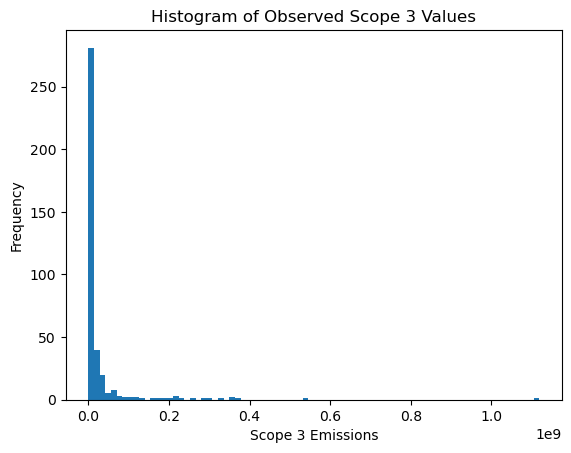

In [115]:

plt.hist(scope3_obs, bins=80)
plt.title("Histogram of Observed Scope 3 Values")
plt.xlabel("Scope 3 Emissions")
plt.ylabel("Frequency")
plt.show()


In [116]:
#print(f"Min: {scope3_obs.min()}, Max: {scope3_obs.max()}")


In [117]:

columns = ["Scope 1", "Scope 2", "Revenue", "float_mcap", "Carbon Intensity", "Scope 3"]
sector_columns = [col for col in gics.columns if col.startswith("Sector_")]
all_cols = columns + sector_columns
# Convert all boolean columns to int (0/1)
bool_cols = gics.select_dtypes(include='bool').columns
gics[bool_cols] = gics[bool_cols].astype(int)

# Subset the data
data = gics[all_cols].copy().reset_index(drop=True)
# Show all columns with object dtype
# Step 1: Get all object columns
object_cols = data.select_dtypes(include="object").columns

# Step 2: Convert them to float
for col in object_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Initialize kernel (this builds multiple trees for imputation)
kernel = mf.ImputationKernel(
    data=data,
    num_datasets=3,
    mean_match_candidates=5,
    random_state=1
)

# Run MICE with PMM
kernel.mice(5)  # 5 iterations

# Extract imputed dataset
completed_data = kernel.complete_data(dataset=0)
# Identify missing Scope 3 values before imputation
missing_mask_original = gics["Scope 3"].isna() 
# Replace back into original
gics.reset_index(drop=True, inplace=True)
missing_mask = gics["Scope 3"].isna() 

gics['Scope 1'] = completed_data["Scope 1"]
gics['Scope 2'] = completed_data["Scope 2"]
gics["Scope 3"] = completed_data["Scope 3"]

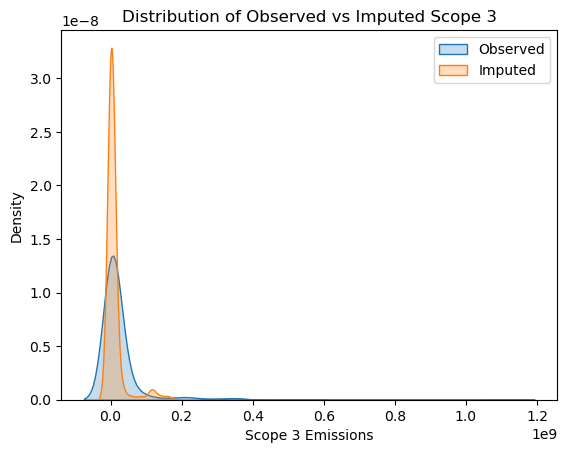

In [118]:
# Separate imputed and observed
imputed_values = gics.loc[missing_mask, "Scope 3"]
observed_values = gics.loc[~missing_mask, "Scope 3"]

# Plot
sns.kdeplot(observed_values, label="Observed", fill=True)
sns.kdeplot(imputed_values, label="Imputed", fill=True)
plt.title("Distribution of Observed vs Imputed Scope 3")
plt.xlabel("Scope 3 Emissions")
plt.ylabel("Density")
plt.legend()
plt.show()

- to do: calculate point to point deviation between observed scope 3 and predicted, could look at scatter plot by sector

In [119]:
#gics = pd.merge(gics_original, gics[['TYPE', 'Scope 3']], how = 'left', left_on = 'TYPE', right_on = 'TYPE')

In [120]:
# gics['Scope 3'] = gics['Scope 3_x'].fillna(gics['Scope 3_y'])
# gics.drop(columns=['Scope 3_x', 'Scope 3_y'], inplace=True)

In [121]:
gics['Scope 1+2+3'] = gics[['Scope 1', 'Scope 2', 'Scope 3']].sum(axis = 1)
gics['Carbon Intensity'] = gics['Scope 1+2+3']/gics['Revenue']
gics.isna().any()

NAME                             False
TYPE                             False
SYMBOL                           False
GICS Sector                      False
ffnosh last day dic 22           False
Price last day dic 22            False
weight_in_sector                 False
float_mcap                       False
Scope 1                          False
Scope 2                          False
Scope 3                          False
Revenue                          False
Scope 1+2+3                      False
Carbon Intensity                 False
AnonID                           False
Sector_Communication Services    False
Sector_Consumer Discretionary    False
Sector_Consumer Staples          False
Sector_Energy                    False
Sector_Financials                False
Sector_Health Care               False
Sector_Industrials               False
Sector_Information Technology    False
Sector_Materials                 False
Sector_Real Estate               False
Sector_Utilities         

## 5) Fetch from Yahoo finance the adjusted price for corporate splits and dividends/capital gains (on LSEG is only adjusted for splits) -> to calculate covariance matrix

In [122]:
# # Define the tickers and date range
# tickers = list(gics['SYMBOL'].values) # Add more tickers as needed
# start_date = "2019-12-01"
# end_date = "2022-12-31"

# # Download the data
# data = yf.download(tickers, start=start_date, end=end_date, group_by='ticker', auto_adjust=False, progress=False)

# # Extract adjusted close prices
# adj_close = pd.DataFrame()

# # If only one ticker, yfinance doesn't use a multi-indexed DataFrame, handle accordingly
# if len(tickers) == 1:
#     adj_close[tickers[0]] = data['Adj Close']
# else:
#     for ticker in tickers:
#         try:
#             adj_close[ticker] = data[ticker]['Adj Close']
#         except KeyError:
#             #print(f"No data found for {ticker}.")

# # Display the result
# #print(adj_close.head())



9 Failed downloads:
['SBNY']: YFPricesMissingError('possibly delisted; no price data found  (1d 2019-12-01 -> 2022-12-30) (Yahoo error = "Data doesn\'t exist for startDate = 1575176400, endDate = 1672376400")')
['DISH', 'CTLT', 'WRK', 'ATVI', 'MRO', 'SIVBQ', 'PXD']: YFTzMissingError('possibly delisted; no timezone found')
['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2019-12-01 -> 2022-12-30)')


In [123]:
# #print(gics.loc[gics['SYMBOL'] == 'BF.B'])
# # Define the tickers and date range
# tickers = ['BF-B'] # Add more tickers as needed
# start_date = "2019-12-01"
# end_date = "2022-12-31"

# # Download the data
# data_bfb = yf.download(tickers, start=start_date, end=end_date, group_by='ticker', auto_adjust=False, progress=False)

# # Extract adjusted close prices
# adj_close_bfb = pd.DataFrame()

# # If only one ticker, yfinance doesn't use a multi-indexed DataFrame, handle accordingly
# if len(tickers) == 1:
#     adj_close_bfb[tickers[0]] = data_bfb['BF-B']['Adj Close']
# else:
#     for ticker in tickers:
#         try:
#             adj_close_bfb[ticker] = data_bfb[ticker]['Adj Close']
#         except KeyError:
#             #print(f"No data found for {ticker}.")

# # Display the result
# #print(adj_close_bfb.head())
# adj_close['BF.B'] = adj_close_bfb.values

In [124]:
# adj_close.to_excel("Data/adj_prices_yahoo_comp_1222.xlsm")

In [125]:
adj_close = pd.read_excel("Data/adj_prices_yahoo_comp_1222.xlsm")

In [126]:
adj_close.index = adj_close.Date

In [127]:
adj_close.drop(columns='Date', inplace=True)

## 6) Fill in missing data from adjusted prices calculated manually or by refetching from Yahoo with the correct Symbol:

In [128]:
price = pd.read_excel('Data/price_div_comp_1222.xlsm', sheet_name='CLOSE PRICE', header = 4)
price.columns = price.columns.str.replace(r'\(.*?\)', '', regex=True).str.strip()
#print(price.iloc[239:])
price = price.iloc[239:]

div_rate = pd.read_excel('Data/price_div_comp_1222.xlsm', sheet_name='DIV RATE', header = 4)
div_rate.columns = div_rate.columns.str.replace(r'\(.*?\)', '', regex=True).str.strip()
div_rate = div_rate.iloc[239:]

div_date = pd.read_excel('Data/price_div_comp_1222.xlsm', sheet_name='DIV DATE', header = 4)
div_date.columns = div_date.columns.str.replace(r'\(.*?\)', '', regex=True).str.strip()
div_date = div_date.iloc[239:]

div_date.columns = price.columns
div_rate.columns = price.columns

price.index = price.Code
div_rate.index = div_rate.Code
div_date.index = div_date.Code

price = price.iloc[:, 1:]
div_rate = div_rate.iloc[:, 1:]
div_date = div_date.iloc[:, 1:]

# --- Step 1: Calculate adjustment factors
adj_factors = pd.DataFrame(1.0, index=price.index, columns=price.columns)

for company in price.columns:
    for i in range(1, len(price)):
        date = price.index[i]
        prev_date = price.index[i - 1]

        # If ex-dividend happens on this day
        if pd.notna(div_date.at[date, company]):
            div = div_rate.at[date, company]
            price_prev = price.at[prev_date, company]
            if price_prev and price_prev != 0:
                factor = (price_prev - div) / price_prev
                adj_factors.at[date, company] = factor

# --- Step 2: Calculate cumulative adjustment factors in reverse (like Yahoo)
cum_factors = adj_factors.iloc[::-1].cumprod().iloc[::-1]

# --- Step 3: Build adjusted prices
adjusted_prices_calculated = price * cum_factors


In [129]:
#print(gics.loc[gics['SYMBOL'] == 'WRK', 'NAME'])
#print(div_rate['96699P'].unique())
#print(price['96699P'])
#print(adjusted_prices_calculated['96699P'])
adj_close['WRK'] = adjusted_prices_calculated.loc[adj_close.index, '96699P'].values

In [130]:
#print(gics.loc[gics['SYMBOL'] == 'CTLT', 'NAME'])
#print(div_rate['8866F3'].unique())
#print(price['8866F3'])
#print(adjusted_prices_calculated['8866F3'])
adj_close['CTLT'] = adjusted_prices_calculated.loc[adj_close.index, ['8866F3']].values

In [131]:
#print(gics.loc[gics['SYMBOL'] == 'MRO', 'NAME'])
#print(div_rate['544682'].unique())
#print(price['544682'])
#print(adjusted_prices_calculated['544682'])
adj_close['MRO'] = adjusted_prices_calculated.loc[adj_close.index, '544682'].values

In [132]:
#print(gics.loc[gics['SYMBOL'] == 'PXD', 'NAME'])
#print(div_rate['895705'].unique())
#print(price['895705'])
adj_close['PXD'] = adjusted_prices_calculated.loc[adj_close.index, '895705'].values

In [133]:
#print(gics.loc[gics['SYMBOL'] == 'SBNY', ['NAME','TYPE']])
#print(div_rate['28709C'].unique())
#print(price['28709C'])
adj_close['SBNY'] = adjusted_prices_calculated.loc[adj_close.index, '28709C'].values

#print(gics.loc[gics['SYMBOL'] == 'ATVI', ['NAME','TYPE']])
#print(div_rate['312367'].unique())
#print(price['312367'])
adj_close['ATVI'] = adjusted_prices_calculated.loc[adj_close.index, '312367'].values

#print(gics.loc[gics['SYMBOL'] == 'DISH', ['NAME','TYPE']])
#print(div_rate['135448'].unique())
#print(price['135448'])
adj_close['DISH'] = adjusted_prices_calculated.loc[adj_close.index, '135448'].values

#print(gics.loc[gics['SYMBOL'] == 'SIVBQ', ['NAME','TYPE']])
#print(div_rate['518628'].unique())
#print(price['518628'])
adj_close['SIVBQ'] = adjusted_prices_calculated.loc[adj_close.index, '518628'].values

## 7) Calculate log monthly returns for past 3 years:

In [134]:
def calculate_log_monthly_returns(df):
    df = df.replace(0.0, np.nan).dropna(how="all")
    df_monthly = df.resample("M").last()
    df_monthly.index = df_monthly.index.map(lambda x: x.replace(day=15))
    log_returns = np.log(df_monthly).diff().dropna(how="all")
    return log_returns

In [135]:
log_returns = calculate_log_monthly_returns(adj_close)

/var/folders/n9/cy4s67js3v58hhczg4lxj5jr0000gq/T/ipykernel_35971/3896427440.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.resample("M").last()


In [136]:
cols_with_nans = adj_close.columns[adj_close.isna().any()]
#print("Columns with NaNs:", cols_with_nans.tolist())


In [137]:
nan_columns = adj_close.loc[:, adj_close.isna().any(axis=0)]

for col in nan_columns.columns:
    first_valid = nan_columns[col].first_valid_index()
    #print(f"First non-NaN in column '{col}': {first_valid}")


In [138]:
from datetime import datetime
log_returns = log_returns.loc[log_returns.index >= datetime(2020, 12, 15)]

## 6) Calculate covariance by sector:

In [139]:
# Create a dictionary to store covariance matrices by sector
sector_cov_matrices = {}

data = gics[['GICS Sector', 'SYMBOL', 'weight_in_sector', 'Carbon Intensity']] 
# Loop over each unique GICS sector
for sector in data['GICS Sector'].unique():
    # Get list of symbols in this sector
    symbols_in_sector = data[data['GICS Sector'] == sector]['SYMBOL'].tolist()

    # Filter log_returns to only include columns (symbols) in this sector
    sector_returns = log_returns[symbols_in_sector]

    # Drop columns with all NaNs (in case any ticker has no returns)
    sector_returns = sector_returns.dropna(axis=1, how='all')

    # Calculate and store the covariance matrix
    if not sector_returns.empty:
        sector_cov_matrices[sector] = sector_returns.cov()

# Optional: #print or inspect one example
example_sector = list(sector_cov_matrices.keys())[0]
#print(f"Covariance matrix for sector: {example_sector}")
#print(sector_cov_matrices[example_sector])

count_in_cov = 0
for key, value in sector_cov_matrices.items():
    count_in_cov += value.shape[0]
    #print(f"{key}: {value.shape}")
#print(count_in_cov)
with pd.ExcelWriter("Data/sector_cov_matrices_comp_1222.xlsx") as writer:
    for sector, cov_matrix in sector_cov_matrices.items():
        # Excel sheet names can't have certain characters or be too long
        safe_sector = sector[:31].replace('/', '_')
        cov_matrix.to_excel(writer, sheet_name=safe_sector)

In [140]:
count_in_cov

500

In [141]:
log_returns.to_excel("Data/log_returns_comp_1222.xlsx")

In [142]:
adj_close.to_excel("Data/adj_price_yahoo_comp_1222.xlsx")

In [143]:
gics.to_excel("Data/dataset_comp_1222.xlsx")